# Bibliotecas e funções

In [1]:
#!pip install scikit-learn
from etl_cartola import BaseCartola
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

In [41]:
def cria_df_completo(df_cartola:pd.DataFrame, path_df_time:str):
    df_jogador = df_cartola[['TIME', 'JOGADOR', 'MÉDIA']].sort_values(by='MÉDIA',ascending=False).reset_index(drop=True)
    df_time = pd.read_csv('times.csv', sep=';')
    df_time = df_time[['TIME', 'SCORE']]
    df_completo = pd.merge(df_jogador, df_time, how='left', on="TIME")
    df_completo.drop(columns='TIME', inplace=True)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df_completo[['MÉDIA', 'SCORE']] = scaler.fit_transform(df_completo[['MÉDIA', 'SCORE']])
    df_completo.columns = ['jogador', 'score_jogador', 'score_time']
    return df_completo


def cruzamento_jogadores_times(df_jogador:pd.DataFrame, path_df_time:str):
    df_time = pd.read_csv('times.csv', sep=';')
    #df_time = df_time[['TIME', 'SCORE']]
    df_completo = pd.merge(df_jogador, df_time, how='left', on="TIME")
    #df_completo.drop(columns='TIME', inplace=True)
    #scaler = MinMaxScaler(feature_range=(-1, 1))
    #df_completo[['MÉDIA', 'SCORE']] = scaler.fit_transform(df_completo[['MÉDIA', 'SCORE']])
    #df_completo.columns = ['jogador', 'score_jogador', 'score_time']
    return df_completo


def reduzir_dimensionalidade_pca(df, colunas, n_components=2):
    """
    Reduz a dimensionalidade de um DataFrame para o número especificado de componentes.

    Args:
    df: DataFrame com os dados.
    n_components: Número de componentes principais a serem mantidos.

    Returns:
    DataFrame com as novas dimensões.
    """
    df = df[colunas]
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    # Cria um objeto PCA com o número desejado de componentes
    pca = PCA(n_components=n_components)

    # Ajusta o PCA aos dados e transforma os dados
    pca.fit(df_scaled)
    principal_components = pca.transform(df_scaled)

    # Cria um novo DataFrame com os componentes principais
    principal_df = pd.DataFrame(data = principal_components, columns = ['principal component 1', 'principal component 2'])

    return principal_df


def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))


def gerar_pontos_aleatorios(N):
  """
  Gera N pontos aleatórios (x,y) no intervalo [-1, 1].

  Args:
    N: Número de pontos a serem gerados.

  Returns:
    Um array numpy de dimensão (N, 2) contendo os pontos gerados.
  """
  pontos = np.random.uniform(-1, 1, size=(N, 2))
  return pontos


def kmeans(df, x, y, K, max_iter=100, tol=0.1):
    """
    Executa o algoritmo K-means e visualiza os clusters a cada iteração.

    Args:
        df: DataFrame com as colunas 'x' e 'y'.
        K: Número de clusters.
        max_iter: Número máximo de iterações.
    """
    # Extrai as features
    X = df[[x, y]].values

    # Inicializa os centroides aleatoriamente
    np.random.seed(42)
    centroids = gerar_pontos_aleatorios(N=K)

    all_centroids = []

    for i in range(max_iter):
        # Cria uma matriz para armazenar as distâncias de cada ponto aos centroides
        distances = np.zeros((X.shape[0], K))

        # Calcula as distâncias
        for j in range(K):
            for k in range(X.shape[0]):
                distances[k, j] = euclidean_distance(X[k], centroids[j])

        # Atribui cada ponto ao cluster mais próximo
        labels = np.argmin(distances, axis=1)
        
        # Atualiza os centroides
        for j in range(K):
            centroids[j] = np.mean(X[labels == j], axis=0)

        all_centroids.append(centroids.copy())
        
        # Calcula a maior distância percorrida por qualquer centroide
        if i > 0:
            max_distance = np.max(np.linalg.norm(all_centroids[i] - all_centroids[i-1], axis=1))
            if max_distance < tol:
                print(f"Algoritmo convergiu na iteração {i}")
                break
            
        # Cria o gráfico de dispersão
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')

        # Plota os centroides com marcadores 'X'
        plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', color='black', s=60, linewidths=3)
        
        # Adiciona texto com os rótulos personalizados e coordenadas
        for j, centroid in enumerate(centroids):
            plt.text(centroid[0], centroid[1]+0.05, f"C{j}: [{round(centroid[0],2)},{round(centroid[1],2)}]", fontsize=10, ha='center', va='bottom')
                
        plt.title(f'Iteração {i+1}')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.show()

    return labels, centroids

# Agrupamento

In [10]:
base_cartola = BaseCartola(url = 'https://api.cartola.globo.com/atletas/mercado')
df_cartola = base_cartola.cruza_dataframes()
df_jog_tim = cruzamento_jogadores_times(df_cartola, 'times.csv')


colunas = ['JOGOS', 'ULT', 'MÉDIA', 'G', 'DP', 'A', 'SG',
       'FT', 'FD', 'DS', 'DE', 'PS', 'FF', 'FS', 'I', 'FC', 'CA', 'GS', 'PC',
       'CV', 'GC', 'PP', 'media_G', 'media_DP', 'media_A', 'media_SG',
       'media_FT', 'media_FD', 'media_DS', 'media_DE', 'media_PS', 'media_FF',
       'media_FS', 'media_I', 'media_FC', 'media_CA', 'media_GS', 'media_PC',
       'media_CV', 'media_GC', 'media_PP', 'mandante_G', 'mandante_DP',
       'mandante_A', 'mandante_SG', 'mandante_FT', 'mandante_FD',
       'mandante_DS', 'mandante_DE', 'mandante_PS', 'mandante_FF',
       'mandante_FS', 'mandante_I', 'mandante_FC', 'mandante_CA',
       'mandante_GS', 'mandante_PC', 'mandante_CV', 'mandante_GC',
       'mandante_PP', 'visitante_G', 'visitante_DP', 'visitante_A',
       'visitante_SG', 'visitante_FT', 'visitante_FD', 'visitante_DS',
       'visitante_DE', 'visitante_PS', 'visitante_FF', 'visitante_FS',
       'visitante_I', 'visitante_FC', 'visitante_CA', 'visitante_GS',
       'visitante_PC', 'visitante_CV', 'visitante_GC', 'visitante_PP',
       'PV', 'PE', 'PD', 'SCORE']

df_pca = reduzir_dimensionalidade_pca(df=df_jog_tim, colunas=colunas, n_components=2)

In [4]:
df_cartola.head()

,MIN P/ VAL,JOGOS,rodada_id,TIME,POSIÇÃO,STATUS,ULT,MÉDIA,VAR(C$),PREÇO,...,visitante_CA,visitante_GS,visitante_PC,visitante_CV,visitante_GC,visitante_PP,media_basica,mandante_media_basica,visitante_media_basica,ESCUDO
0,None,17,33,BOT,ATA,Dúvida,8.5,5.78,0.89,7.86,...,0,0,0,0,0,0,3.132941,NaN,NaN,https://s.sde.globo.com/media/organizations/20...
1,None,12,33,BOT,MEI,Dúvida,2.2,2.48,-0.73,6.61,...,0,0,0,0,0,0,1.813333,NaN,NaN,https://s.sde.globo.com/media/organizations/20...
2,None,9,33,VAS,MEI,Nulo,1.2,2.16,-0.31,5.56,...,0,0,0,0,0,0,1.271111,NaN,NaN,https://s.sde.globo.com/media/organizations/20...
3,None,11,33,CAM,MEI,Nulo,0.0,1.02,0.00,5.80,...,0,0,0,0,0,0,1.020000,NaN,NaN,https://s.sde.globo.com/media/organizations/20...
4,None,2,33,CRU,ZAG,Provável,0.0,3.55,0.00,4.56,...,0,0,0,0,0,0,1.050000,NaN,NaN,https://s.sde.globo.com/media/organizations/20...


In [5]:
df_jog_tim.head()

,MIN P/ VAL,JOGOS,rodada_id,TIME,POSIÇÃO,STATUS,ULT,MÉDIA,VAR(C$),PREÇO,...,visitante_GC,visitante_PP,media_basica,mandante_media_basica,visitante_media_basica,ESCUDO,PV,PE,PD,SCORE
0,None,17,33,BOT,ATA,Dúvida,8.5,5.78,0.89,7.86,...,0,0,3.132941,NaN,NaN,https://s.sde.globo.com/media/organizations/20...,0.43,0.28,0.29,0.14
1,None,12,33,BOT,MEI,Dúvida,2.2,2.48,-0.73,6.61,...,0,0,1.813333,NaN,NaN,https://s.sde.globo.com/media/organizations/20...,0.43,0.28,0.29,0.14
2,None,9,33,VAS,MEI,Nulo,1.2,2.16,-0.31,5.56,...,0,0,1.271111,NaN,NaN,https://s.sde.globo.com/media/organizations/20...,0.31,0.30,0.39,-0.08
3,None,11,33,CAM,MEI,Nulo,0.0,1.02,0.00,5.80,...,0,0,1.020000,NaN,NaN,https://s.sde.globo.com/media/organizations/20...,0.29,0.28,0.43,-0.14
4,None,2,33,CRU,ZAG,Provável,0.0,3.55,0.00,4.56,...,0,0,1.050000,NaN,NaN,https://s.sde.globo.com/media/organizations/20...,0.10,0.23,0.67,-0.57


In [6]:
df_pca

,principal component 1,principal component 2
0,5.613072,1.096414
1,0.380434,1.146480
2,-1.203678,-0.277472
3,-0.811903,-0.536477
4,-2.065718,-3.003085
...,...,...
783,-0.697406,-1.015154
784,-2.535792,0.203709
785,-2.660248,-0.609186
786,-2.653980,-0.163574


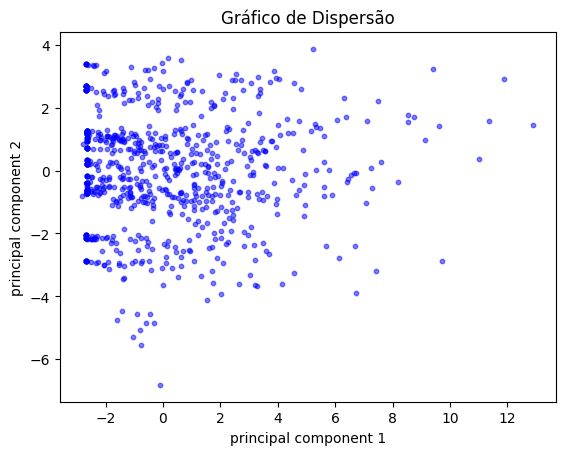

In [11]:
plt.scatter(df_pca['principal component 1'], df_pca['principal component 2'], s=10, c='blue', alpha=0.5)

# Personalizando o gráfico
plt.title('Gráfico de Dispersão')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')

# Mostrando o gráfico
plt.show()

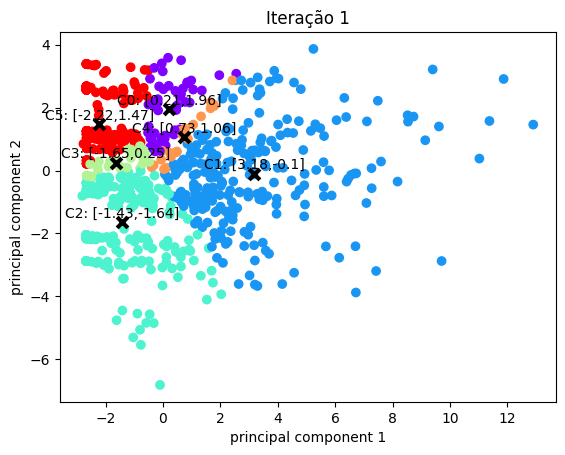

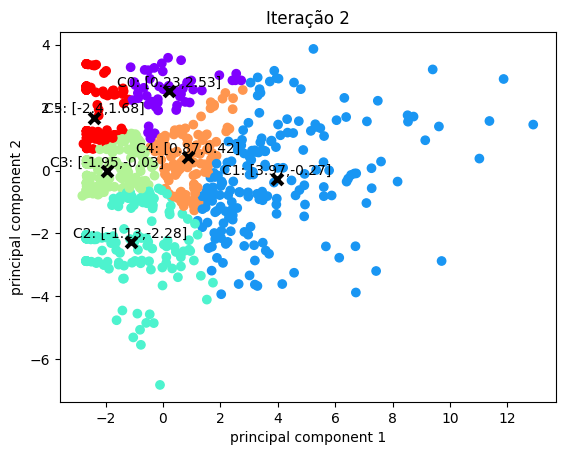

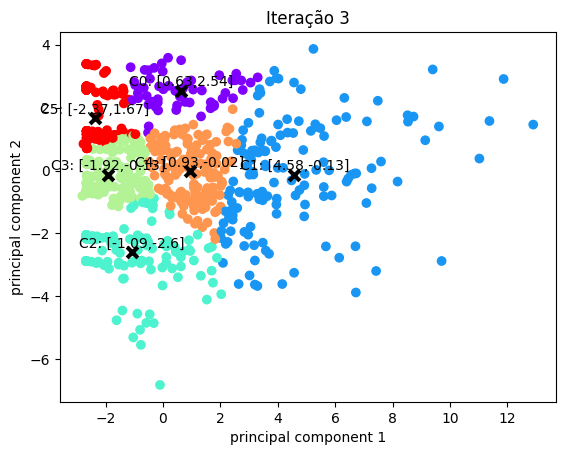

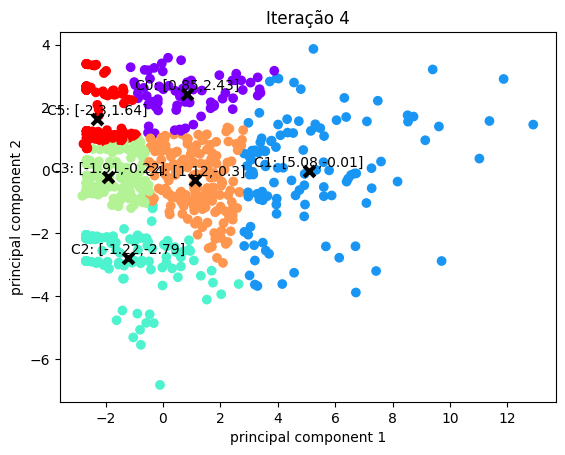

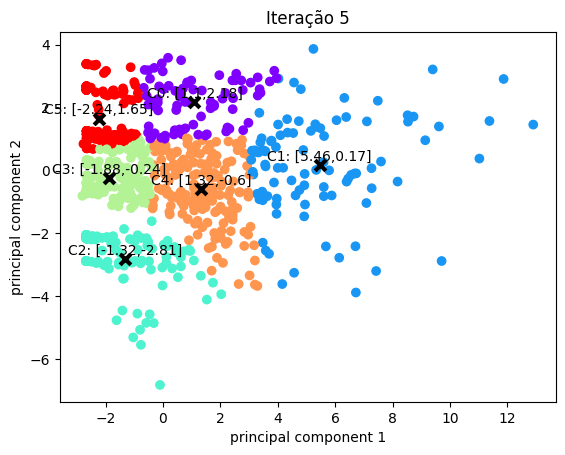

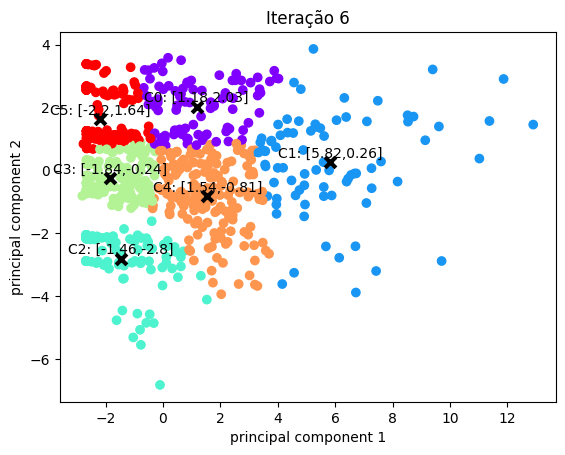

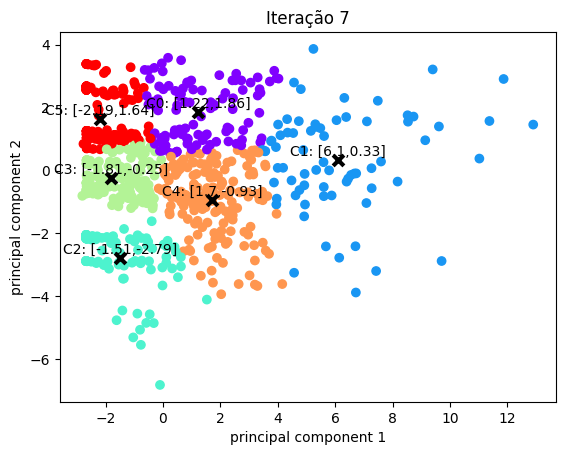

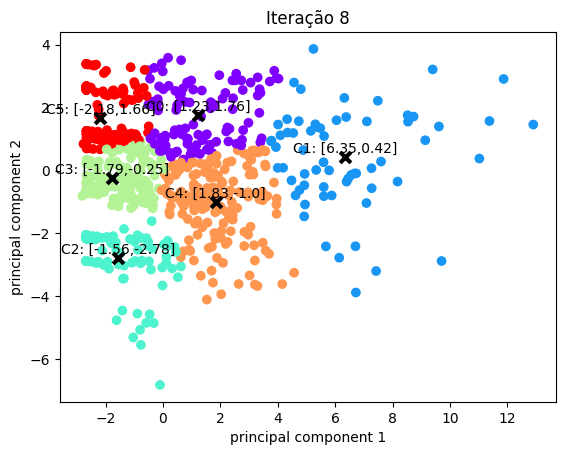

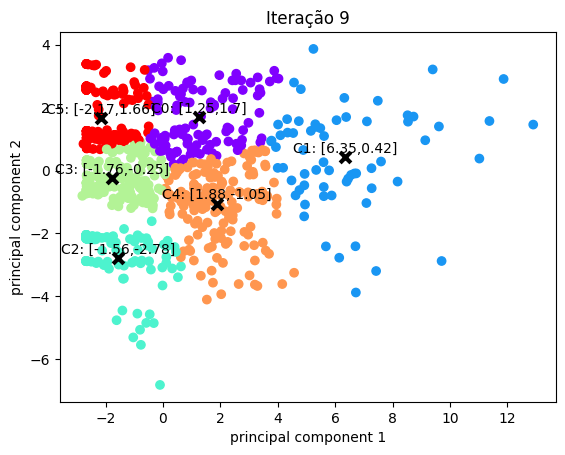

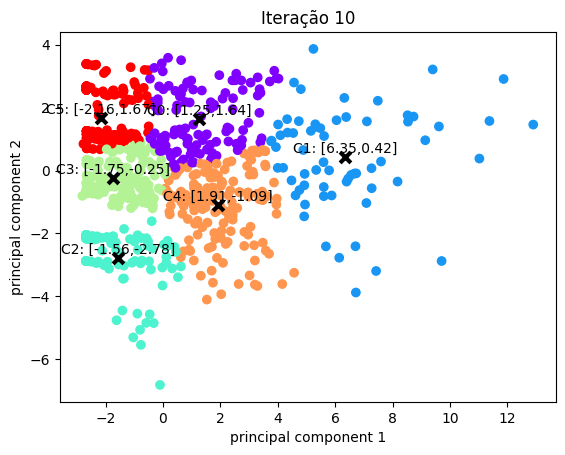

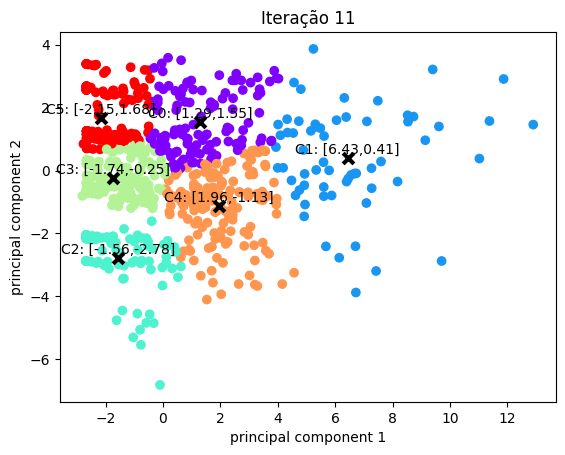

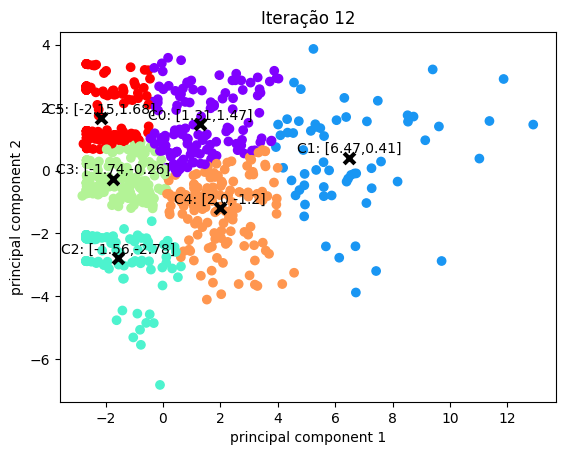

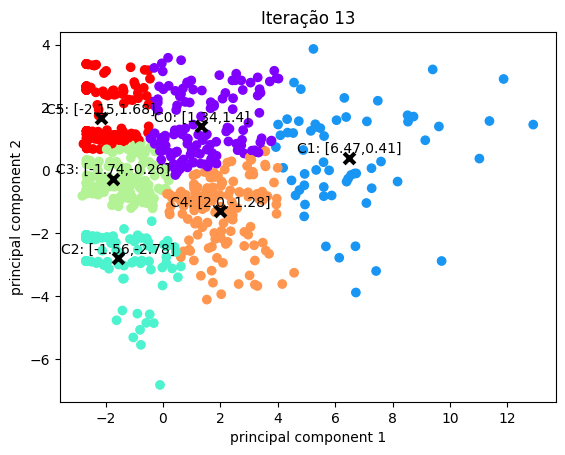

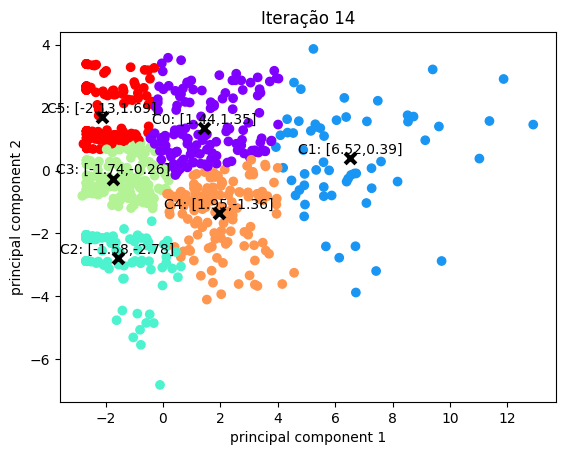

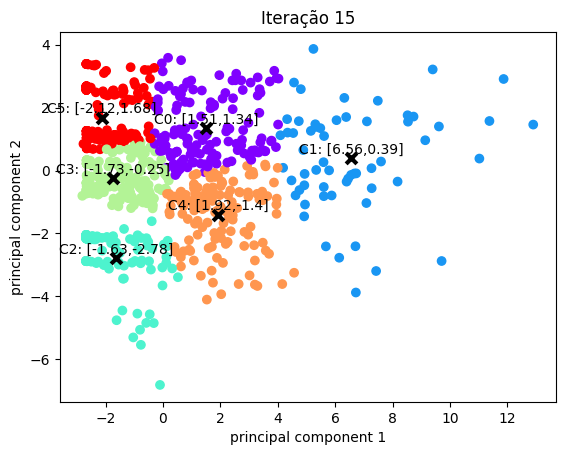

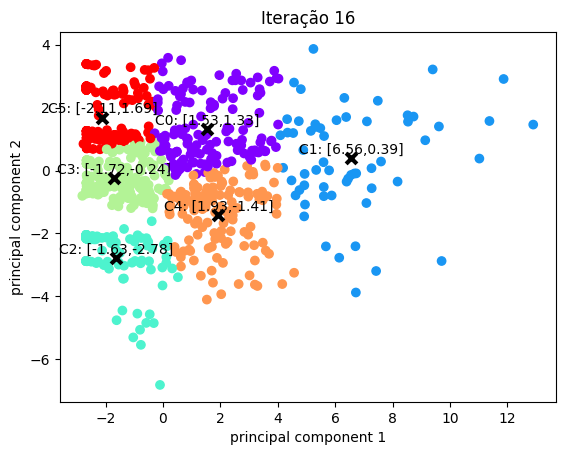

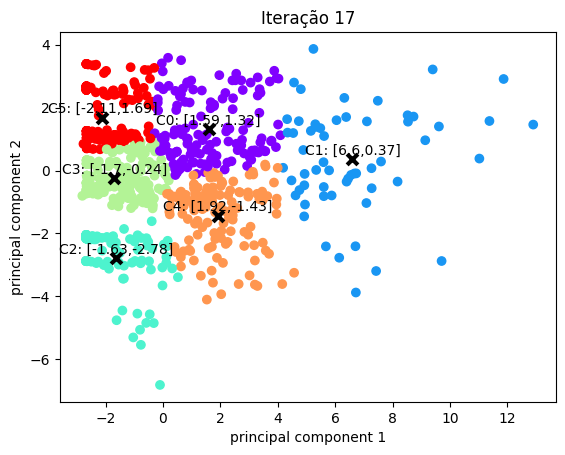

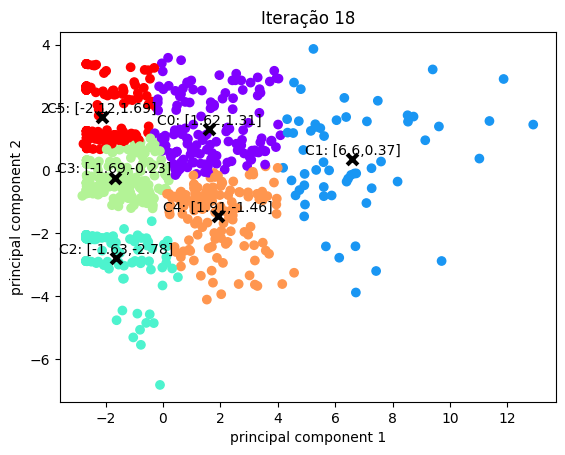

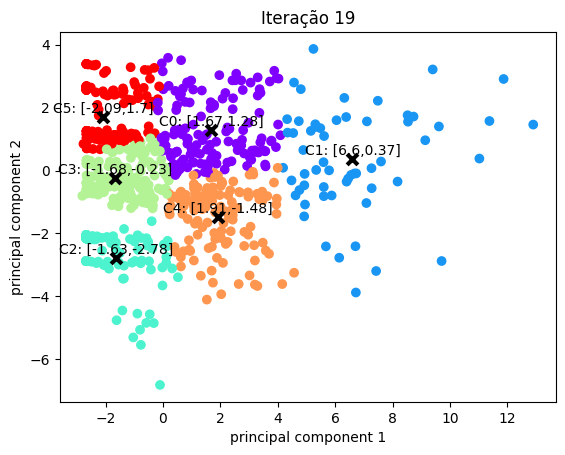

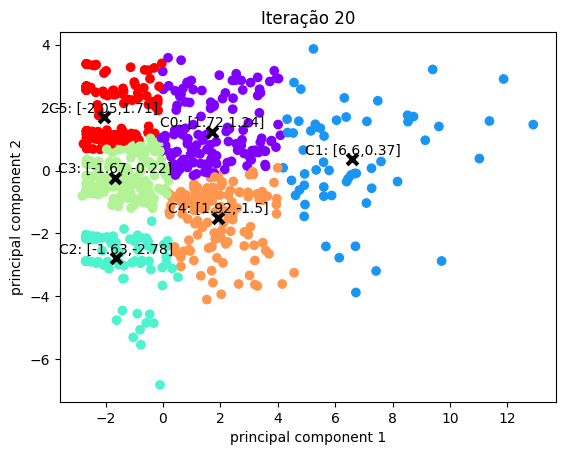

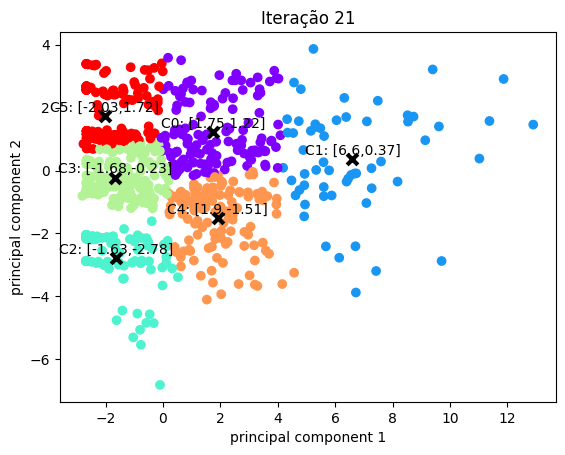

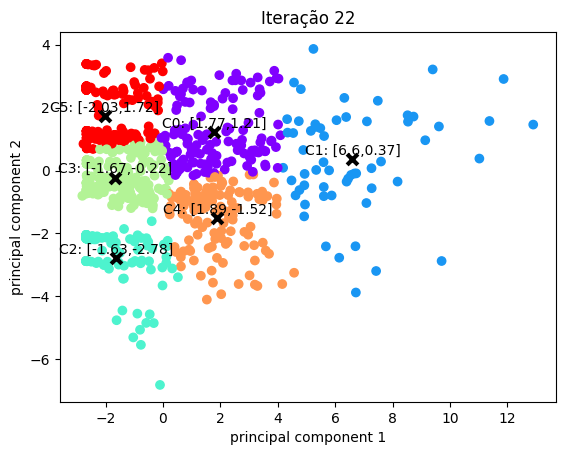

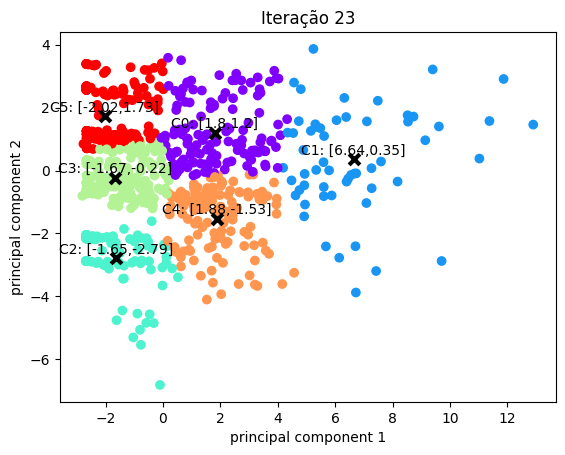

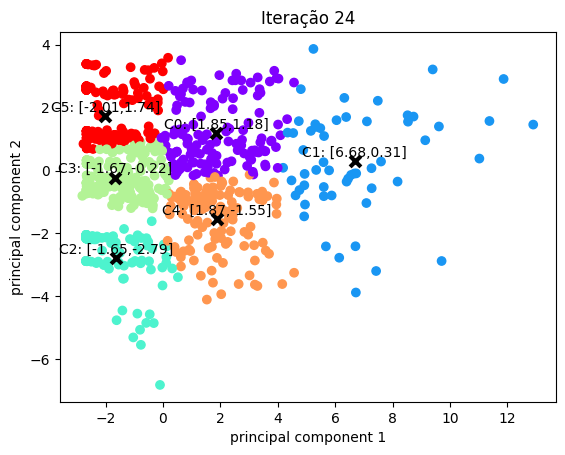

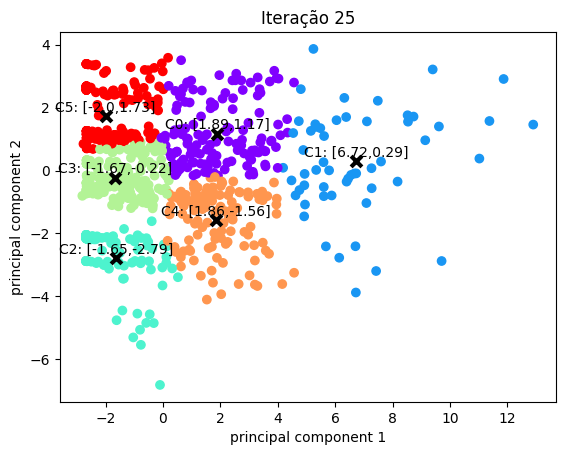

Algoritmo convergiu na iteração 25


In [42]:
labels, centroids = kmeans(df_pca, x='principal component 1', y='principal component 2', K=6, max_iter=100, tol=0.01)

In [15]:
df_jog_tim.columns

Index(['MIN P/ VAL', 'JOGOS', 'rodada_id', 'TIME', 'POSIÇÃO', 'STATUS', 'ULT',
       'MÉDIA', 'VAR(C$)', 'PREÇO',
       ...
       'visitante_GC', 'visitante_PP', 'media_basica', 'mandante_media_basica',
       'visitante_media_basica', 'ESCUDO', 'PV', 'PE', 'PD', 'SCORE'],
      dtype='object', length=101)

In [23]:
df_jog_tim['cluster'] = labels
df_interpretacao = df_jog_tim[['cluster','MÉDIA', 'G', 'A', 'SG', 'DS', 'SCORE']]

In [24]:
df_interpretacao['cluster'].value_counts()

cluster
3    206
5    178
0    139
4    118
2     92
1     55
Name: count, dtype: int64

In [25]:
media_por_cluster = df_interpretacao.groupby('cluster').mean()
media_por_cluster

,MÉDIA,G,A,SG,DS,SCORE
cluster,,,,,,
0,3.413885,1.589928,1.280576,1.805755,20.287770,0.207122
1,4.989818,5.200000,3.054545,0.418182,27.236364,-0.004727
2,1.886957,0.206522,0.032609,1.663043,2.663043,-0.405652
3,1.591602,0.174757,0.116505,0.669903,3.825243,-0.054320
4,3.083305,1.067797,0.906780,2.805085,24.186441,-0.228729
5,1.150337,0.089888,0.056180,0.331461,2.455056,0.289551


* **Cluster 0:** jogadores bons dos times favoritos da rodada
* **Cluster 1:** meias, atacantes e laterais mais ofensivos com as maiores médias
* **Cluster 2:** jogadores dos times "desfavoritos" da rodada
* **Cluster 3:** cluster misto
* **Cluster 4:** jogadores com maiores números de SG e desarmes
* **Cluster 5:** jogadores ruins e técnicos dos times favoritos da rodada

In [43]:
# Cluster 0: jogadores bons dos times favoritos da rodada
df_jog_tim[df_jog_tim['cluster'] == 0][['TIME', 'JOGADOR', 'POSIÇÃO', 'MÉDIA', 'G', 'A', 'SG', 'DS', 'FD', 'FF']].sort_values(by='MÉDIA', ascending=False).head(20).reset_index(drop=True)

,TIME,JOGADOR,POSIÇÃO,MÉDIA,G,A,SG,DS,FD,FF
0,INT,Bernabéi,LAT,7.62,3,2,4,29,4,5
1,GRE,Braithwaite,ATA,7.32,5,2,0,3,4,6
2,FLA,Arrascaeta,MEI,7.26,5,5,0,14,7,9
3,FLA,De la Cruz,MEI,6.65,2,2,0,23,5,8
4,PAL,Piquerez,LAT,6.23,2,0,7,22,5,15
5,COR,Memphis Depay,ATA,5.70,3,1,0,2,2,4
6,CAP,Nikão,MEI,5.64,4,2,0,20,10,15
7,BOT,Mateo Ponte,LAT,5.63,3,0,5,28,0,4
8,INT,Alan Patrick,MEI,5.59,6,2,0,14,8,9
9,INT,Renê,LAT,5.21,0,1,5,24,3,4


In [30]:
# Cluster 1: meias, atacantes e laterais mais ofensivos com as maiores médias
df_jog_tim[df_jog_tim['cluster'] == 1][['TIME', 'JOGADOR', 'POSIÇÃO', 'MÉDIA', 'G', 'A', 'SG', 'DS', 'FD', 'FF']].sort_values(by='MÉDIA', ascending=False).head(20).reset_index(drop=True)

,TIME,JOGADOR,POSIÇÃO,MÉDIA,G,A,SG,DS,FD,FF
0,CAM,Hulk,ATA,8.26,9,3,0,4,8,24
1,FLA,Pedro,ATA,7.90,11,5,0,15,15,11
2,PAL,Estêvão,ATA,7.88,11,8,0,27,19,18
3,CRU,William,LAT,7.32,5,3,10,75,9,20
4,SAO,Lucas Moura,MEI,7.21,9,5,0,33,10,9
5,COR,Garro,MEI,7.20,7,9,0,42,20,17
6,INT,Wesley,ATA,7.13,8,1,0,41,18,19
7,BOT,Cuiabano,LAT,6.81,4,3,9,38,8,8
8,FLU,Arias,MEI,6.76,5,1,0,32,12,17
9,INT,Borré,ATA,6.62,6,2,0,18,11,17


In [46]:
# Cluster 2: técnicos, goleiros e zagueiros dos times "desfavoritos" da rodada
cluster2 = df_jog_tim[df_jog_tim['cluster'] == 2][['TIME','JOGADOR', 'POSIÇÃO', 'MÉDIA', 'G', 'A', 'SG', 'DS', 'FD', 'FF', 'PV', 'PD', 'SCORE']].sort_values(by='MÉDIA', ascending=False).reset_index(drop=True)
cluster2.head(20)

,TIME,JOGADOR,POSIÇÃO,MÉDIA,G,A,SG,DS,FD,FF,PV,PD,SCORE
0,ACG,Marcão,ZAG,7.50,0,0,0,3,1,0,0.16,0.60,-0.44
1,ACG,Haller,LAT,5.90,0,0,1,1,0,0,0.16,0.60,-0.44
2,FOR,Juan Vojvoda,TEC,5.53,0,0,0,0,0,0,0.27,0.44,-0.17
3,PAL,Weverton,GOL,5.06,0,1,14,1,0,0,0.42,0.30,0.12
4,ACG,Anderson Gomes,TEC,5.02,0,0,0,0,0,0,0.16,0.60,-0.44
5,FOR,João Ricardo,GOL,4.97,0,0,11,1,0,0,0.27,0.44,-0.17
6,CRU,Dinenno,ATA,4.95,3,0,0,1,3,1,0.10,0.67,-0.57
7,BOT,John,GOL,4.84,0,0,15,0,0,0,0.43,0.29,0.14
8,CRU,Kaiki Bruno,LAT,4.53,0,0,5,26,1,5,0.10,0.67,-0.57
9,FLU,Fábio,GOL,4.48,0,0,9,1,0,0,0.44,0.27,0.17


In [49]:
# Cluster 3: cluster misto
df_jog_tim[df_jog_tim['cluster'] == 3][['TIME','JOGADOR', 'POSIÇÃO', 'MÉDIA', 'G', 'A', 'SG', 'DS', 'FD', 'FF']].sort_values(by='MÉDIA', ascending=False).head(20).reset_index(drop=True)

,TIME,JOGADOR,POSIÇÃO,MÉDIA,G,A,SG,DS,FD,FF
0,VAS,Lyncon,ZAG,8.00,1,0,0,0,0,0
1,VAS,GB,ATA,6.55,1,0,0,3,0,2
2,VIT,Muriel,GOL,6.50,0,0,1,0,0,0
3,BOT,Vitinho,LAT,6.33,0,0,5,12,0,1
4,PAL,Abel Ferreira,TEC,6.28,0,0,0,0,0,0
5,BOT,Artur Jorge,TEC,6.08,0,0,0,0,0,0
6,BOT,Alex Telles,LAT,5.61,0,1,5,4,1,4
7,SAO,João Moreira,LAT,5.53,0,0,2,4,1,0
8,FLU,Thiago Silva,ZAG,5.50,0,0,7,7,1,1
9,INT,Roger Machado,TEC,5.43,0,0,0,0,0,0


In [29]:
# Cluster 4: jogadores com maiores números de SG e desarmes
df_jog_tim[df_jog_tim['cluster'] == 4][['TIME','JOGADOR', 'POSIÇÃO', 'MÉDIA', 'G', 'A', 'SG', 'DS', 'FD', 'FF']].sort_values(by='MÉDIA', ascending=False).head(20).reset_index(drop=True)

,TIME,JOGADOR,POSIÇÃO,MÉDIA,G,A,SG,DS,FD,FF
0,FOR,Mancuso,LAT,6.99,1,1,3,13,4,4
1,JUV,Ronaldo,MEI,5.94,2,2,0,12,1,2
2,CAM,Rubens,LAT,5.15,0,1,2,32,0,8
3,BGT,Juninho Capixaba,LAT,5.08,0,0,5,49,2,4
4,CAM,Guilherme Arana,LAT,4.92,1,1,4,23,8,8
5,JUV,João Lucas,LAT,4.81,1,5,4,38,4,10
6,FOR,Emmanuel Martínez,MEI,4.58,1,4,0,22,1,5
7,JUV,Edson Carioca,ATA,4.55,3,1,0,12,2,4
8,CAM,Paulinho,ATA,4.53,6,1,0,20,11,8
9,BOT,Alexander Barboza,ZAG,4.43,0,1,13,30,7,9


In [38]:
# Cluster 5: cluster dos times favoritos da rodada
cluster5 = df_jog_tim[df_jog_tim['cluster'] == 5][['TIME','JOGADOR', 'POSIÇÃO', 'MÉDIA', 'G', 'A', 'SG', 'DS', 'FD', 'FF', 'PV', 'PD', 'SCORE']].sort_values(by='MÉDIA', ascending=False).reset_index(drop=True)
cluster5.head(20)

,TIME,JOGADOR,POSIÇÃO,MÉDIA,G,A,SG,DS,FD,FF,PV,PD,SCORE
0,FLA,Felipe Teresa,ATA,8.00,1,0,0,0,0,0,0.45,0.27,0.18
1,FLA,Filipe Luís,TEC,6.41,0,0,0,0,0,0,0.45,0.27,0.18
2,GRE,Igor,LAT,6.30,0,1,1,2,0,1,0.59,0.17,0.42
3,COR,Ramón Díaz,TEC,5.50,0,0,0,0,0,0,0.67,0.10,0.57
4,FLU,Mano Menezes,TEC,5.50,0,0,0,0,0,0,0.44,0.27,0.17
5,FLA,Michael,ATA,5.38,2,0,0,2,3,3,0.45,0.27,0.18
6,BOT,Adryelson,ZAG,5.30,0,0,2,2,0,1,0.43,0.29,0.14
7,FLU,Ignácio,ZAG,5.03,0,0,1,7,0,1,0.44,0.27,0.17
8,CAP,Lucho González,TEC,4.89,0,0,0,0,0,0,0.60,0.16,0.44
9,GRE,Renato Gaúcho,TEC,4.73,0,0,0,0,0,0,0.59,0.17,0.42


# Rascunhos

In [13]:
"""
df_jog_tim.drop(columns=['MIN P/ VAL',
    'FOTO',
    'media_pontos_mandante',
    'media_pontos_visitante',
    'media_minutos_jogados',
    'minutos_jogados',
    'media_basica',
    'mandante_media_basica',
    'visitante_media_basica'],
    inplace=True)
"""

"\ndf_jog_tim.drop(columns=['MIN P/ VAL',\n    'FOTO',\n    'media_pontos_mandante',\n    'media_pontos_visitante',\n    'media_minutos_jogados',\n    'minutos_jogados',\n    'media_basica',\n    'mandante_media_basica',\n    'visitante_media_basica'],\n    inplace=True)\n"